## Cross correlation and other methods

In [26]:
import pandas as pd
import numpy as np
import tqdm as tqdm

appended_data = pd.read_csv('raw_appended_data.csv')
dtw = pd.read_csv('aligned_dtw_data.csv')

In [4]:
import numpy as np

def compute_cross_correlation(x, y, lag_max=None):
    x = (x - np.mean(x)) / (np.std(x) + 1e-8)
    y = (y - np.mean(y)) / (np.std(y) + 1e-8)
    
    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x) + 1, len(x))

    if lag_max is not None:
        mask = (lags >= -lag_max) & (lags <= lag_max)
        return lags[mask], corr[mask]
    return lags, corr


In [ ]:
import numpy as np
import pandas as pd

def compute_pairwise_cross_correlation(appended_data, target_feature='hand_velocity', lag_max=50):
    """
    Computes pairwise cross-correlation between affected and unaffected trials for each participant.
    
    Parameters:
    - appended_data: DataFrame containing the kinematic data, including columns 'participant_id', 'condition', and 'trial_number'.
    - target_feature: The kinematic feature (e.g., 'hand_velocity') to be analyzed for cross-correlation.
    - lag_max: The maximum lag to consider for the cross-correlation computation.
    
    Returns:
    - DataFrame with results including participant IDs, affected/unaffected trial pairs, max correlation, and lag at max correlation.
    """
    results = []
    
    for pid, group in appended_data.groupby('participant_id'):
        affected_trials = group[group['condition'] == 'affected'].groupby('trial_number')
        unaffected_trials = group[group['condition'] == 'unaffected'].groupby('trial_number')
        
        # Pair trials based on index order — assumes trials are balanced
        for (aff_num, aff_trial), (unaff_num, unaff_trial) in zip(affected_trials, unaffected_trials):
            affected = aff_trial[target_feature].reset_index(drop=True)
            unaffected = unaff_trial[target_feature].reset_index(drop=True)

            # Ensure the trials are of the same length
            min_len = min(len(affected), len(unaffected))
            if min_len < 10:
                continue  # skip short or mismatched trials

            affected = affected[:min_len]
            unaffected = unaffected[:min_len]

            # Compute cross-correlation
            lags, corr = compute_cross_correlation(affected.values, unaffected.values, lag_max=lag_max)

            # Append the results
            results.append({
                'participant_id': pid,
                'affected_trial': aff_num,
                'unaffected_trial': unaff_num,
                'max_corr': np.max(corr),
                'lag_at_max_corr': lags[np.argmax(corr)],
                'corr_array': corr,
                'lags_array': lags
            })
    
    # Convert the results to a DataFrame
    return pd.DataFrame(results)

cross_corr_df = compute_pairwise_cross_correlation(appended_data, target_feature='hand_velocity', lag_max=50)
cross_corr_df_dtw = compute_pairwise_cross_correlation(dtw, target_feature='hand_velocity', lag_max=50)

In [38]:
import numpy as np
import pandas as pd

def compute_normalized_cross_correlation(signal_1, signal_2, lag_max=50):
    """
    Compute the cross-correlation of two signals and normalize the result to be between -1 and 1.

    Parameters:
    - signal_1, signal_2: 1D arrays (or lists) of the signals to be cross-correlated.
    - lag_max: Maximum lag to consider for the cross-correlation computation.

    Returns:
    - lags: The lag values.
    - normalized_corr: The normalized cross-correlation values.
    """
    # Compute cross-correlation
    corr = np.correlate(signal_1, signal_2, mode='full')
    
    # Normalize the correlation to be between -1 and 1
    corr = corr / (np.std(signal_1) * np.std(signal_2) * len(signal_1))  # Normalize by std and length
    
    # Generate lag values based on the correlation result length
    lags = np.arange(-len(signal_1) + 1, len(signal_1))  # Ensure lag values correspond to the corr size

    # Return the lag values and the normalized correlation
    return lags, corr

# Example usage in your function:
def compute_pairwise_cross_correlation(appended_data, target_feature='hand_velocity', lag_max=50):
    results = []
    
    for pid, group in appended_data.groupby('participant_id'):
        affected_trials = group[group['condition'] == 'affected'].groupby('trial_number')
        unaffected_trials = group[group['condition'] == 'unaffected'].groupby('trial_number')
        
        # Pair trials based on index order — assumes trials are balanced
        for (aff_num, aff_trial), (unaff_num, unaff_trial) in zip(affected_trials, unaffected_trials):
            affected = aff_trial[target_feature].reset_index(drop=True)
            unaffected = unaff_trial[target_feature].reset_index(drop=True)

            # Ensure the trials are of the same length
            min_len = min(len(affected), len(unaffected))
            if min_len < 10:
                continue  # skip short or mismatched trials

            affected = affected[:min_len]
            unaffected = unaffected[:min_len]

            # Compute normalized cross-correlation
            lags, corr = compute_normalized_cross_correlation(affected.values, unaffected.values, lag_max=lag_max)

            # Ensure the index for max correlation is within bounds of lags array
            if np.argmax(corr) < len(lags):
                results.append({
                    'participant_id': pid,
                    'affected_trial': aff_num,
                    'unaffected_trial': unaff_num,
                    'max_corr': np.max(corr),
                    'lag_at_max_corr': lags[np.argmax(corr)],
                    'corr_array': corr,
                    'lags_array': lags
                })
    
    # Convert the results to a DataFrame
    return pd.DataFrame(results)

# Example usage:
cross_corr_df_dtw = compute_pairwise_cross_correlation(dtw, target_feature='hand_velocity', lag_max=50)


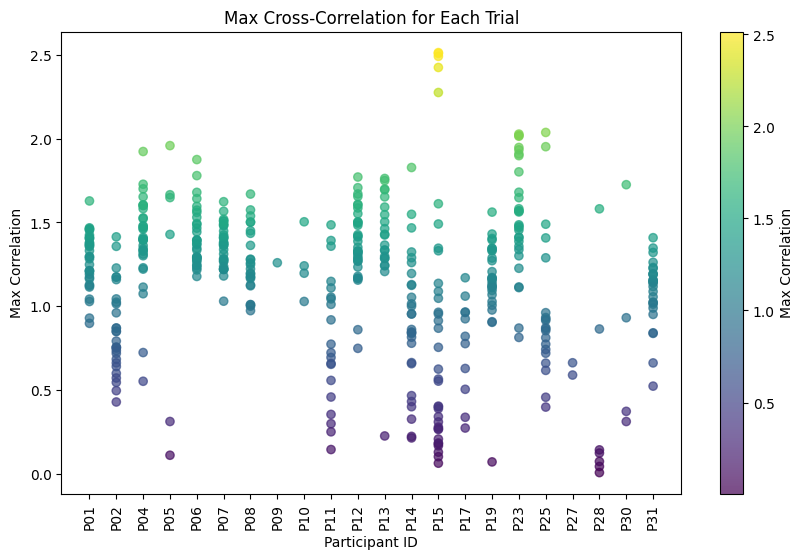

In [39]:
import matplotlib.pyplot as plt

# Plotting max correlation for each trial
plt.figure(figsize=(10, 6))
plt.scatter(cross_corr_df_dtw['participant_id'], cross_corr_df_dtw['max_corr'], c=cross_corr_df_dtw['max_corr'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Max Correlation')
plt.title('Max Cross-Correlation for Each Trial')
plt.xlabel('Participant ID')
plt.ylabel('Max Correlation')
plt.xticks(rotation=90)  # Rotate participant IDs for better visibility
plt.show()


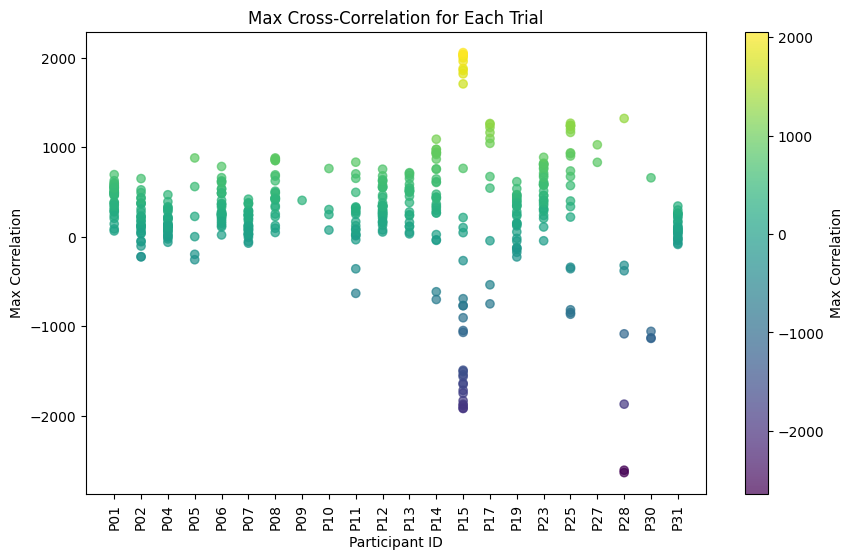

In [30]:
import matplotlib.pyplot as plt

# Plotting max correlation for each trial
plt.figure(figsize=(10, 6))
plt.scatter(cross_corr_df_dtw['participant_id'], cross_corr_df_dtw['max_corr'], c=cross_corr_df_dtw['max_corr'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Max Correlation')
plt.title('Max Cross-Correlation for Each Trial')
plt.xlabel('Participant ID')
plt.ylabel('Max Correlation')
plt.xticks(rotation=90)  # Rotate participant IDs for better visibility
plt.show()


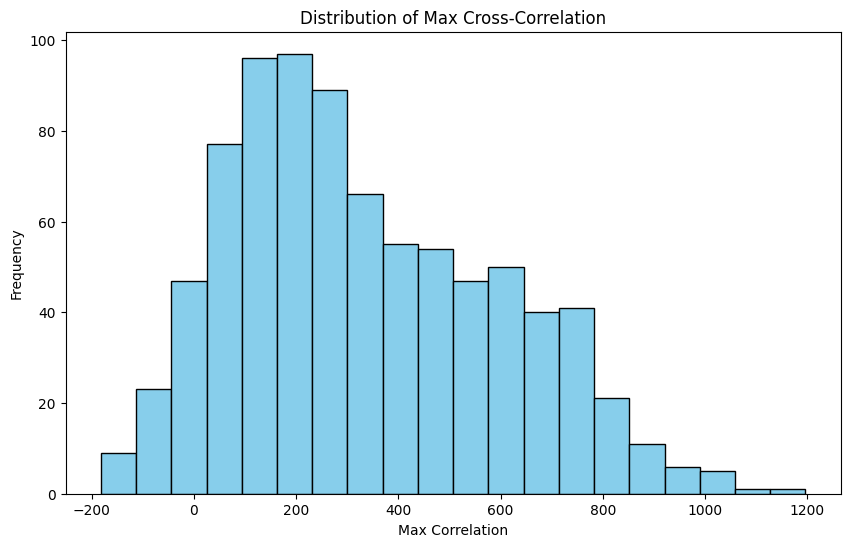

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(cross_corr_df['max_corr'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Max Cross-Correlation')
plt.xlabel('Max Correlation')
plt.ylabel('Frequency')
plt.show()


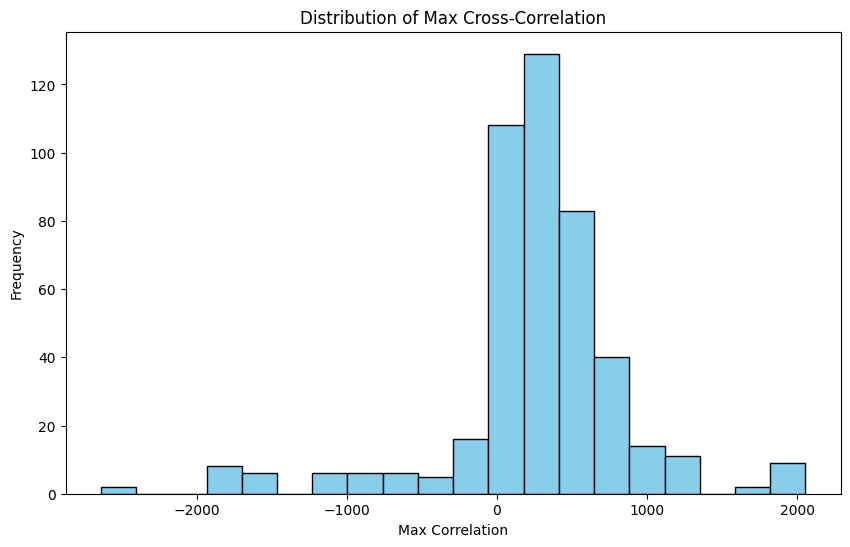

In [31]:
plt.figure(figsize=(10, 6))
plt.hist(cross_corr_df_dtw['max_corr'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Max Cross-Correlation')
plt.xlabel('Max Correlation')
plt.ylabel('Frequency')
plt.show()


<Figure size 1000x600 with 0 Axes>

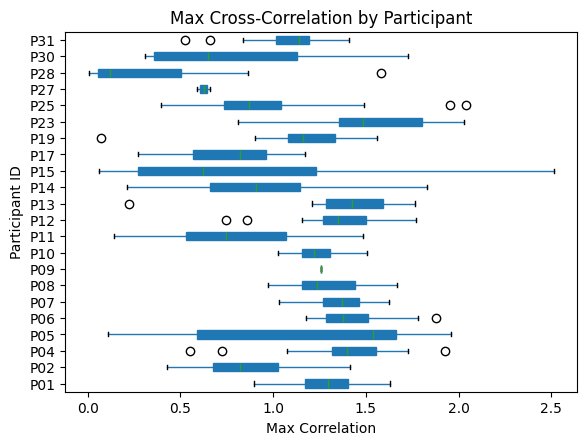

In [40]:
plt.figure(figsize=(10, 6))
cross_corr_df_dtw.boxplot(column='max_corr', by='participant_id', grid=False, patch_artist=True, vert=False)
plt.title('Max Cross-Correlation by Participant')
plt.suptitle('')  # Remove the default title
plt.xlabel('Max Correlation')
plt.ylabel('Participant ID')
plt.show()
